# KBM width oracle: which extent does it select, and what predicts the width?

Fusion_PhD-38e9.6. `kbm_extent_filter.ipynb` (cells 57-64) found that choosing GFTM's WIDTH per case in 0.3-0.8 cuts the
error ~3x from the best fixed width, but the growth and frequency oracles disagree on the width and pile up at the range
ends. Two questions, on the same KBM data (FILTER=0.5, NBASIS 22, NXGRID 28; GS2 `pyro_cube_avg` reference):

1. **Physics.** Does the oracle width make GFTM select a very different eigenfunction **extent**, or the same one?
2. **Prediction.** Does the oracle width follow the case's physics parameters (the 8 `kbm_8d` hypercube axes)?

Oracles (all consult GS2, so they are **bounds**, never accuracies), each against two targets, growth
|log10(gamma/gamma_GS2)| and frequency |omega - omega_GS2|:

- **(D) dominant mode**: at each width take argmax gamma over unstable modes; pick the width per case.
- **(A) all modes**: pick the (width, mode) pair per case from all four modes.

Conventions copied from `kbm_extent_filter.ipynb`: population = cases with GS2 gamma finite and > 0; a MISS (no unstable
mode) scores gamma = 0 (|log10| error = inf) and omega = 0. Extent is pyro's `Extent` (95% of |Re field|^2), phi and A_par.
Main result over widths 0.3-0.8; repeated over all 24 widths (0.2-4.0) because choices pile up at the ends; and
repeated on the GS2 cases the GA consensus classifier labels KBM (`general_analysis.mode_classification`, as in 38e9.5).

## Imports and settings

In [1]:
from pathlib import Path
import os
import warnings
from multiprocessing import get_context
from dotenv import load_dotenv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
from scipy.stats import spearmanr
import pyrokinetics
from pyrokinetics import Pyro
from pyrokinetics.pyroscan import PyroScanGKOutput
from pyrokinetics.diagnostics.extent import Extent
from general_analysis import mode_classification as mc

ROOT = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").is_file() and (path / "notebooks").is_dir()
)
plt.style.use(ROOT / "src/general_analysis/paper.mplstyle")
load_dotenv(ROOT / "local.env", override=True)
print("pyrokinetics", pyrokinetics.__version__)

analysis_name = "kbm_width_oracle_physics"
data_root = Path(os.environ["GK_DATA_ROOT"]).expanduser()
run_template = "Runs"
project = "LATIN_HYPERCUBE"
cases = {"SPR-045": "SPR-045", "M1": "M1"}  # database label -> case directory
scan_information = {"GFTM": "kbm_8d/wo_{width}", "GFTM_f05": "kbm_8d/wo_f05_{width}", "GS2": "kbm_8d"}
output_dir = {"GFTM": "pyro_cube", "GS2": "pyro_cube_avg"}  # GS2: tail-averaged reference
output_file = "cube.nc"
widths = ["w0p2000", "w0p2297", "w0p2639", "w0p3031", "w0p3482", "w0p4000", "w0p4595",
          "w0p5279", "w0p6063", "w0p6965", "w0p8000", "w0p9000", "w1p0000", "w1p1000",
          "w1p2000", "w1p3000", "w1p4000", "w1p5000", "w1p6000", "w1p9218", "w2p3083",
          "w2p7726", "w3p3302", "w4p0000"]
width_value = {w: float(w[1:].replace("p", ".")) for w in widths}
expected_resolution = {"nbasis_used": 22, "nxgrid_used": 28}
filter_requested = 0.5

fraction = 0.95                     # Extent's rule: theta range holding 95% of |Re field|^2
fields = ["phi", "apar"]
field_labels = {"phi": r"$\phi$", "apar": r"$A_\parallel$"}
width_oracle_range = (0.3, 0.8)     # main result, as in kbm_extent_filter cell 59
near_optimal = (0.10, 0.25, 0.50)   # near-optimal widths: error <= (1 + x) * oracle error
targets = ["growth", "frequency"]

# the 8 kbm_8d hypercube axes, read from the GS2 cube's sample coordinates
params = ["ky", "q", "shat", "beta", "deuterium_temp_gradient", "electron_temp_gradient",
          "electron_dens_gradient", "electron_nu"]
param_labels = {"ky": r"$k_y\rho$", "q": r"$q$", "shat": r"$\hat{s}$", "beta": r"$\beta$",
                "deuterium_temp_gradient": r"$a/L_{T_i}$", "electron_temp_gradient": r"$a/L_{T_e}$",
                "electron_dens_gradient": r"$a/L_n$", "electron_nu": r"$\nu_e$"}
n_bins = 5        # quantile bins for the binned-median plots
n_boot = 1000     # bootstrap resamples (bands and rho intervals)
n_folds = 5       # cross-validated R^2 of the joint fit
rng = np.random.default_rng(0)
fs_title, fs_label, fs_tick, fs_legend = 16, 16, 14, 12   # PLOTTING_AND_PUBLISHING 4a
plt.rcParams.update({"axes.labelsize": fs_label, "xtick.labelsize": fs_tick, "ytick.labelsize": fs_tick,
                     "legend.fontsize": fs_legend, "axes.titlesize": fs_title})

pyrokinetics 0.9.2.dev142+g959db5f4


## Load data

GS2 reference and the FILTER=0.5 `wo_f05_*` cubes at all 24 widths, with `Extent` added in place. The FILTER=0.0
`wo_*` cubes are loaded only over 0.3-0.8, to reproduce `kbm_extent_filter` cell 60 (both arms) as a check.

In [2]:
def cube(code, case, scan):
    return PyroScanGKOutput.from_netcdf(data_root / code / run_template / project / case / scan
                                        / output_dir["GS2" if code == "GS2" else "GFTM"] / output_file)

gs2, gftm05, gftm00 = {}, {}, {}
for db, case in cases.items():
    gs2[db] = cube("GS2", case, scan_information["GS2"])
    Extent(gs2[db], fraction=fraction)
    for w in widths:
        gftm05[db, w] = cube("GFTM", case, scan_information["GFTM_f05"].format(width=w))
        Extent(gftm05[db, w], fraction=fraction)
        if width_oracle_range[0] <= width_value[w] <= width_oracle_range[1]:
            gftm00[db, w] = cube("GFTM", case, scan_information["GFTM"].format(width=w))
    print(db, "GS2 samples", gs2[db].data.sizes["sample"], "| FILTER=0.5 cubes", len(widths))

SPR-045 GS2 samples 300 | FILTER=0.5 cubes 24


M1 GS2 samples 300 | FILTER=0.5 cubes 24


## Assemble (case, width, mode) arrays

Checked, not assumed: FILTER used (from `out.gftm.localdump`) is 0.5 and the resolution/WIDTH used are the requested
ones in every sample; every cube has the same samples in the same order; both codes share pyro units. Parameters come
from the GS2 cube's own sample coordinates, aligned by `sample_name`.

In [3]:
def mag(v):
    return np.asarray(getattr(v.data, "magnitude", v.data))


def select(gam, keep):
    # argmax growth over 'mode' among unstable modes passing `keep`; 0 where none passes (a MISS)
    g = np.where(keep & (gam > 0), gam, -np.inf)
    idx = g.argmax(axis=1)
    return np.where(np.isfinite(g.max(axis=1)), gam[np.arange(len(gam)), idx], 0.0), idx


def assemble(db, cubes, ws, with_extent):
    ref = gs2[db].data
    names = cubes[db, ws[0]].data.sample_name.values
    ref_idx = pd.Index(ref.sample_name.values).get_indexer(names)
    assert (ref_idx >= 0).all(), f"{db}: GFTM samples missing from GS2"
    g_ref = mag(ref.growth_rate)[ref_idx]
    ok = np.isfinite(g_ref) & (g_ref > 0)
    v = dict(names=names[ok], g_ref=g_ref[ok], f_ref=mag(ref.mode_frequency)[ref_idx][ok], widths=np.array([width_value[w] for w in ws]),
             params=pd.DataFrame({p: mag(ref[p])[ref_idx][ok] for p in params}),
             ext_ref={f: mag(ref.extent.sel(field=f))[ref_idx][ok] for f in fields})
    assert np.isfinite(v["f_ref"]).all()
    gam, freq, ext = [], [], {f: [] for f in fields}
    for w in ws:
        d = cubes[db, w].data
        assert (d.sample_name.values == names).all(), f"{db}/{w}: samples differ between widths"
        assert str(d.growth_rate.data.units) == str(ref.growth_rate.data.units), "growth normalisations differ"
        assert str(d.mode_frequency.data.units) == str(ref.mode_frequency.data.units), "frequency normalisations differ"
        for var, value in expected_resolution.items():
            assert (mag(d[var]) == value).all(), f"{db}/{w}: {var} is not {value}"
        assert np.allclose(mag(d.width_used), width_value[w])
        gam.append(mag(d.growth_rate.transpose("sample", "mode"))[ok])
        freq.append(mag(d.mode_frequency.transpose("sample", "mode"))[ok])
        for f in fields if with_extent else []:
            ext[f].append(mag(d.extent.sel(field=f).transpose("sample", "mode"))[ok])
    v.update(gam=np.stack(gam, 1), freq=np.stack(freq, 1),
             ext={f: np.stack(e, 1) for f, e in ext.items() if e})   # (case, width, mode)
    assert np.isfinite(v["freq"][v["gam"] > 0]).all(), f"{db}: unstable-mode frequency is non-finite"
    return v


for (db, w), out in gftm05.items():
    assert (mag(out.data.filter_used) == filter_requested).all() and (mag(out.data.filter_requested) == filter_requested).all()
data05 = {db: assemble(db, gftm05, widths, True) for db in cases}
in_range = [w for w in widths if width_oracle_range[0] <= width_value[w] <= width_oracle_range[1]]
data00 = {db: assemble(db, gftm00, in_range, False) for db in cases}
for db, v in data05.items():
    print(db, "population n =", len(v["names"]), "| widths in range:", [width_value[w] for w in in_range])

SPR-045 population n = 220 | widths in range: [0.3031, 0.3482, 0.4, 0.4595, 0.5279, 0.6063, 0.6965, 0.8]
M1 population n = 252 | widths in range: [0.3031, 0.3482, 0.4, 0.4595, 0.5279, 0.6063, 0.6965, 0.8]


### Parameters: read from the cube, checked against the scan record

The cube's sample coordinates must equal the scan's own `pyroscan.json` parameter values (the hypercube definition
written by PyroScan when the database was built). Ranges printed for the catalogue.

In [4]:
import json
for db, case in cases.items():
    scan = json.loads((data_root / "GS2" / run_template / project / case / scan_information["GS2"] / output_dir["GS2"]
                       / "pyroscan.json").read_text())["parameter_dict"]
    ref = gs2[db].data
    for p in params:
        assert np.allclose(np.ravel(scan[p][0]), mag(ref[p])), f"{db}: {p} differs from pyroscan.json"
    print(db, "parameters agree with pyroscan.json")
param_ranges = pd.concat({db: pd.DataFrame({p: [mag(gs2[db].data[p]).min(), mag(gs2[db].data[p]).max()] for p in params},
                                           index=["min", "max"]).T for db in cases}, axis=1)
print(param_ranges.to_string(float_format="%.4g"))
# Latin hypercube: near-orthogonal axes, so 1-D trends should agree with the joint fit
for db, v in data05.items():
    rho = v["params"].corr(method="spearman").values
    print(db, "max |Spearman rho| between axes (population):", np.abs(rho[~np.eye(len(params), dtype=bool)]).max().round(3))

SPR-045 parameters agree with pyroscan.json
M1 parameters agree with pyroscan.json
                          SPR-045                M1        
                              min     max       min     max
ky                       0.007091  0.1402   0.01903   1.615
q                           2.014   8.984     2.013   8.735
shat                      -0.9872    4.99    0.1131   4.984
beta                     0.001065  0.2901 5.327e-05  0.1703
deuterium_temp_gradient    0.1208   8.994    0.5159   7.933
electron_temp_gradient     0.1156   8.922   0.01858   7.978
electron_dens_gradient    -0.9897   5.979   0.04668   5.962
electron_nu             0.0002346 0.09963 0.0005128 0.09917
SPR-045 max |Spearman rho| between axes (population): 0.649
M1 max |Spearman rho| between axes (population): 0.594


## Oracles

`oracles(v, iw, keep)` scores one database over the candidate widths `iw` on the cases in `keep`, and returns per case,
for each (oracle, target): the chosen width, mode and error, and the selected mode's extent. `fixed` is the single best
width (lowest median error, in-sample) with its dominant-mode extent.

In [5]:
def oracles(v, iw, keep):
    gam, freq = v["gam"][keep][:, iw], v["freq"][keep][:, iw]
    g_ref, f_ref = v["g_ref"][keep], v["f_ref"][keep]
    n, nw, nm = gam.shape
    r = np.arange(n)
    unstable = gam > 0
    hit = unstable.any(2)
    i_dom = np.where(unstable, gam, -np.inf).argmax(2)                       # (case, width)
    g_dom = np.where(hit, np.take_along_axis(gam, i_dom[..., None], 2)[..., 0], 0.0)
    f_dom = np.where(hit, np.take_along_axis(freq, i_dom[..., None], 2)[..., 0], 0.0)   # a MISS predicts omega = 0
    with np.errstate(divide="ignore", invalid="ignore"):
        err_d = {"growth": np.abs(np.log10(g_dom / g_ref[:, None])), "frequency": np.abs(f_dom - f_ref[:, None])}
        err_a = {"growth": np.where(unstable, np.abs(np.log10(gam / g_ref[:, None, None])), np.inf),
                 "frequency": np.where(unstable, np.abs(freq - f_ref[:, None, None]), np.inf)}
    ext = {f: v["ext"][f][keep][:, iw] for f in v["ext"]}
    ext_dom = {f: np.where(hit, np.take_along_axis(e, i_dom[..., None], 2)[..., 0], np.nan) for f, e in ext.items()}
    res = dict(n=n, widths=v["widths"][iw], err_d=err_d, ext_dom=ext_dom, i_dom=i_dom,
               params=v["params"][keep].reset_index(drop=True), ext_ref={f: e[keep] for f, e in v["ext_ref"].items()})
    for t in targets:
        jw = err_d[t].argmin(1)
        res["D", t] = dict(jw=jw, mode=i_dom[r, jw], err=err_d[t][r, jw], miss=~hit[r, jw],
                           ext={f: e[r, jw] for f, e in ext_dom.items()})
        flat = err_a[t].reshape(n, -1)
        jw_a, m_a = np.divmod(flat.argmin(1), nm)
        any_a = unstable.any((1, 2))
        err = np.where(any_a, flat.min(1), np.inf if t == "growth" else np.abs(f_ref))  # no unstable mode anywhere: a MISS
        res["A", t] = dict(jw=jw_a, mode=m_a, err=err, miss=~any_a,
                           ext={f: np.where(any_a, e[r, jw_a, m_a], np.nan) for f, e in ext.items()})
        j_fix = int(np.argmin(np.median(err_d[t], axis=0)))
        res["fixed", t] = dict(jw=np.full(n, j_fix), mode=i_dom[:, j_fix], err=err_d[t][:, j_fix], miss=~hit[:, j_fix],
                               ext={f: e[:, j_fix] for f, e in ext_dom.items()})
    return res


iw_range = np.flatnonzero((data05["SPR-045"]["widths"] >= width_oracle_range[0]) & (data05["SPR-045"]["widths"] <= width_oracle_range[1]))
iw_all = np.arange(len(widths))
everyone = {db: np.ones(len(v["names"]), bool) for db, v in data05.items()}
main = {db: oracles(v, iw_range, everyone[db]) for db, v in data05.items()}

### Reproduction check: `kbm_extent_filter` cell 64

Growth medlog and frequency medAE, best fixed width -> width oracle (D), FILTER=0.5; and, for both filter arms, the
fraction of oracle choices at the range ends and the growth/frequency agreement.

In [6]:
for db, res in main.items():
    print(f"{db} FILTER=0.5: growth medlog fixed {np.median(res['fixed', 'growth']['err']):.3f} (W={res['widths'][res['fixed', 'growth']['jw'][0]]:g}) "
          f"-> oracle {np.median(res['D', 'growth']['err']):.3f} | frequency medAE fixed {np.median(res['fixed', 'frequency']['err']):.3f} "
          f"(W={res['widths'][res['fixed', 'frequency']['jw'][0]]:g}) -> oracle {np.median(res['D', 'frequency']['err']):.3f}")
for arm, data in (("FILTER=0.0", data00), ("FILTER=0.5", data05)):
    for db, v in data.items():
        iw = np.arange(len(in_range)) if arm == "FILTER=0.0" else iw_range
        res = oracles(v, iw, everyone[db])
        jg, jf = res["D", "growth"]["jw"], res["D", "frequency"]["jw"]
        ends = lambda j: np.isin(j, (0, len(iw) - 1)).mean()
        print(f"{db} {arm}: at an end growth {ends(jg):.0%}, frequency {ends(jf):.0%}; same width {np.mean(jg == jf):.0%}")

SPR-045 FILTER=0.5: growth medlog fixed 0.096 (W=0.8) -> oracle 0.030 | frequency medAE fixed 0.013 (W=0.6965) -> oracle 0.003
M1 FILTER=0.5: growth medlog fixed 0.065 (W=0.4595) -> oracle 0.017 | frequency medAE fixed 0.045 (W=0.6965) -> oracle 0.015
SPR-045 FILTER=0.0: at an end growth 43%, frequency 35%; same width 27%
M1 FILTER=0.0: at an end growth 35%, frequency 28%; same width 21%
SPR-045 FILTER=0.5: at an end growth 42%, frequency 38%; same width 22%
M1 FILTER=0.5: at an end growth 40%, frequency 31%; same width 17%


## Q1: does the oracle width change the selected extent?

`log(Extent Ratio)` is log10 of the ratio of 95% extents. For each (oracle, target): the selected mode against GS2,
against the dominant mode at the best fixed width, and (within a case) the spread of the dominant mode's extent over
all candidate widths and over the near-optimal ones.

In [7]:
def lr(a, b):
    with np.errstate(divide="ignore", invalid="ignore"):
        return np.log10(a / b)


def spread(res, t, f, x=None):
    # log10(max/min) of the dominant-mode extent over the case's candidate widths (near-optimal ones if x is given)
    e, err = res["ext_dom"][f], res["err_d"][t]
    m = np.isfinite(e) if x is None else np.isfinite(e) & (err <= (1 + x) * res["D", t]["err"][:, None])
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        return np.log10(np.nanmax(np.where(m, e, np.nan), 1) / np.nanmin(np.where(m, e, np.nan), 1))


def q1_rows(res, db, label):
    rows = []
    for o in ("D", "A"):
        for t in targets:
            s, fx = res[o, t], res["fixed", t]
            row = dict(db=db, set=label, oracle=o, target=t, n=res["n"], medErr_fixed=np.median(fx["err"]),
                       medErr_oracle=np.median(s["err"]), W_fixed=res["widths"][fx["jw"][0]],
                       frac_at_end=np.isin(s["jw"], (0, len(res["widths"]) - 1)).mean(), miss=int(s["miss"].sum()))
            for f in fields:
                a, b, g = lr(s["ext"][f], res["ext_ref"][f]), lr(fx["ext"][f], res["ext_ref"][f]), lr(s["ext"][f], fx["ext"][f])
                row |= {f"{f}_medAbsLog_oracle_vs_gs2": np.nanmedian(np.abs(a)), f"{f}_medAbsLog_fixed_vs_gs2": np.nanmedian(np.abs(b)),
                        f"{f}_medLog_oracle_vs_fixed": np.nanmedian(g), f"{f}_frac_oracle_within2_fixed": np.mean(np.abs(g[np.isfinite(g)]) <= np.log10(2))}
                if o == "D":
                    row |= {f"{f}_medSpread_all": np.nanmedian(spread(res, t, f))}
                    row |= {f"{f}_medSpread_{int(x * 100)}pct": np.nanmedian(spread(res, t, f, x)) for x in near_optimal}
                    row |= {f"{f}_fracSpread_gt2_{int(x * 100)}pct": np.nanmean(spread(res, t, f, x) > np.log10(2)) for x in near_optimal}
            if o == "D":
                # how many candidate widths are near-optimal (a set of 1 has spread 0 trivially)
                row |= {f"medN_near_{int(x * 100)}pct": np.median((res["err_d"][t] <= (1 + x) * s["err"][:, None]).sum(1)) for x in near_optimal}
            if o == "A":
                d = res["D", t]
                nondom = s["mode"] != res["i_dom"][np.arange(res["n"]), s["jw"]]
                ext_dom_at_A = {f: res["ext_dom"][f][np.arange(res["n"]), s["jw"]] for f in fields}
                row |= {f"{f}_medAbsLog_A_vs_dom_where_nondominant": np.nanmedian(np.abs(lr(s["ext"][f], ext_dom_at_A[f])[nondom])) for f in fields}
                row |= {f"{f}_frac_A_vs_dom_gt2_where_nondominant": np.nanmean(np.abs(lr(s["ext"][f], ext_dom_at_A[f])[nondom]) > np.log10(2)) for f in fields}
                row |= {f"{f}_medAbsLog_A_vs_D_where_nondominant": np.nanmedian(np.abs(lr(s["ext"][f], d["ext"][f])[nondom])) for f in fields}
                row |= dict(frac_A_nondominant=np.mean(nondom),
                            frac_A_same_width_as_D=np.mean(s["jw"] == d["jw"]),
                            **{f"{f}_medAbsLog_A_vs_D": np.nanmedian(np.abs(lr(s["ext"][f], d["ext"][f]))) for f in fields})
            rows.append(row)
    g, fq = res["D", "growth"], res["D", "frequency"]
    rows[0] |= dict(frac_growth_freq_same_width=np.mean(g["jw"] == fq["jw"]),
                    **{f"{f}_medAbsLog_growth_vs_freq": np.nanmedian(np.abs(lr(g["ext"][f], fq["ext"][f]))) for f in fields},
                    **{f"{f}_frac_growth_freq_within2": np.nanmean(np.abs(lr(g["ext"][f], fq["ext"][f])) <= np.log10(2)) for f in fields})
    return rows


q1 = pd.DataFrame([r for db, res in main.items() for r in q1_rows(res, db, "0.3-0.8")])
pd.set_option("display.width", 250, "display.max_columns", 60)
print(q1.T.round(3).to_string())

                                                  0          1         2          3         4          5         6          7
db                                          SPR-045    SPR-045   SPR-045    SPR-045        M1         M1        M1         M1
set                                         0.3-0.8    0.3-0.8   0.3-0.8    0.3-0.8   0.3-0.8    0.3-0.8   0.3-0.8    0.3-0.8
oracle                                            D          D         A          A         D          D         A          A
target                                       growth  frequency    growth  frequency    growth  frequency    growth  frequency
n                                               220        220       220        220       252        252       252        252
medErr_fixed                               0.096497   0.013174  0.096497   0.013174   0.06549   0.044617   0.06549   0.044617
medErr_oracle                              0.030311   0.003363  0.017587   0.002316  0.016692   0.015343  0.010368   0

### Q1 plots

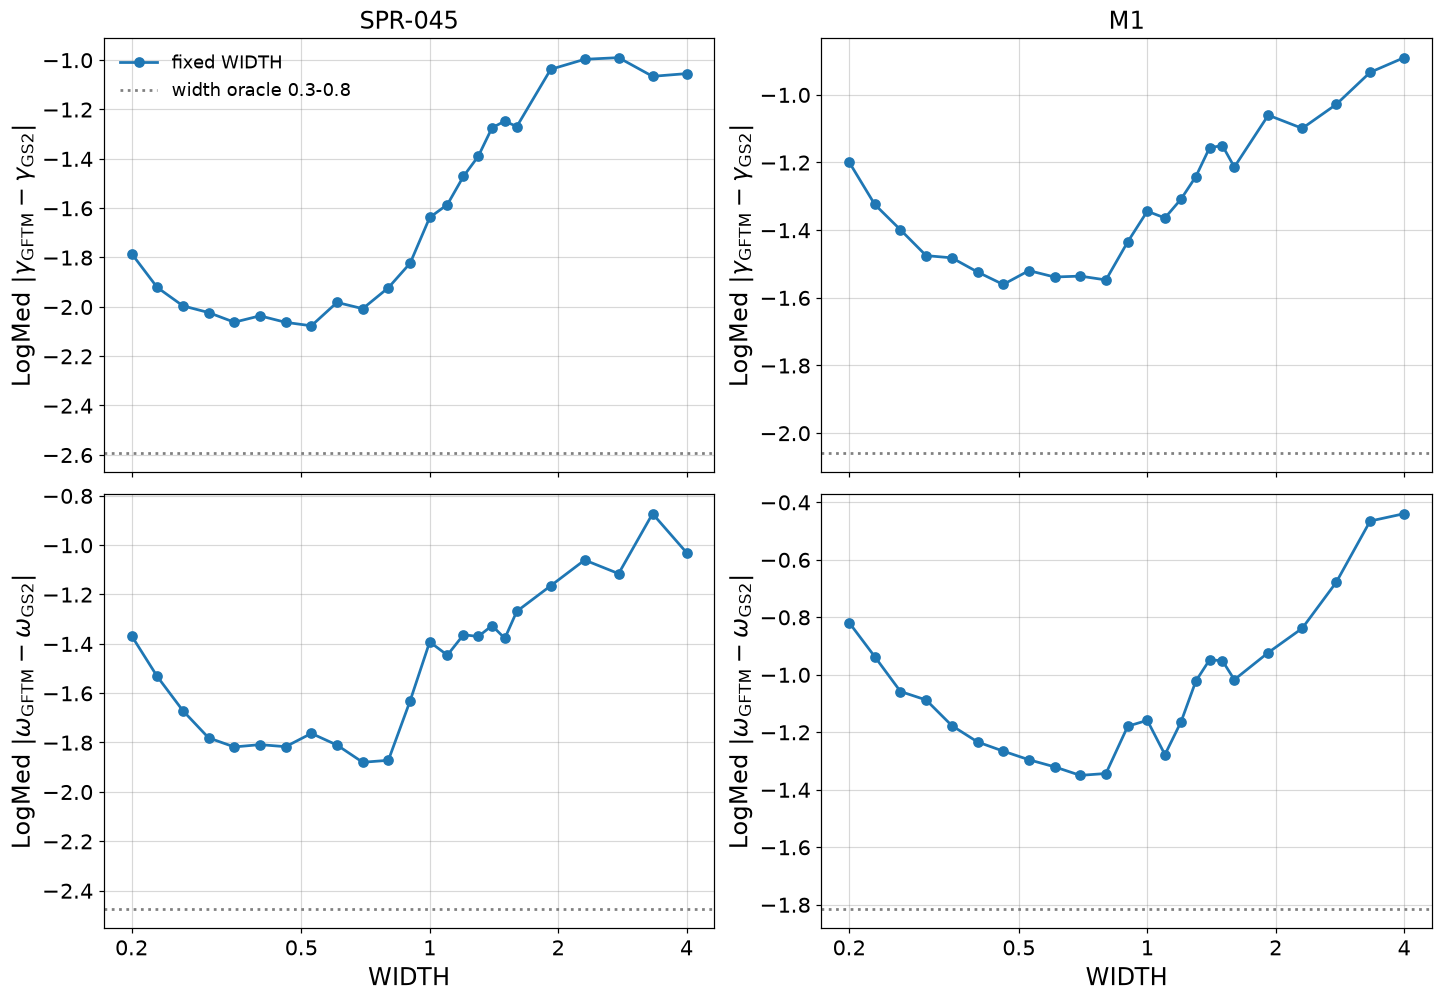

In [8]:
def set_log_ticks(ax, ticks):
    lims = ax.get_xlim()
    ax.set_xticks(ticks)
    ax.set_xlim(lims)
    ax.xaxis.set_major_formatter(StrMethodFormatter("{x:g}"))
    ax.minorticks_off()


# every width (0.2-4.0) at fixed WIDTH; the 0.3-0.8 oracles as dotted lines
full = {db: oracles(v, iw_all, everyone[db]) for db, v in data05.items()}
w_all = data05["SPR-045"]["widths"]
ylabel = {"growth": r"LogMed $|\gamma_{\rm GFTM}-\gamma_{\rm GS2}|$", "frequency": r"LogMed $|\omega_{\rm GFTM}-\omega_{\rm GS2}|$"}
fig1, axes1 = plt.subplots(len(targets), len(cases), figsize=(13, 9), sharex=True, squeeze=False)
for col, db in enumerate(cases):
    v, res = data05[db], full[db]
    g_dom = np.where(v["gam"] > 0, v["gam"], -np.inf).max(2)
    for row, t in enumerate(targets):
        ax = axes1[row, col]
        if t == "growth":   # absolute error, as 4a; a MISS predicts gamma = 0
            g_sel = np.where(np.isfinite(g_dom), g_dom, 0.0)
            err = np.abs(g_sel - v["g_ref"][:, None])
            jw = main[db]["D", t]["jw"]
            orc = np.abs(g_sel[:, iw_range][np.arange(len(jw)), jw] - v["g_ref"])
        else:
            err, orc = res["err_d"][t], main[db]["D", t]["err"]
        ax.plot(w_all, np.log10(np.median(err, axis=0)), color="C0", label="fixed WIDTH")
        ax.axhline(np.log10(np.median(orc)), color="0.5", ls=":", marker="", label="width oracle 0.3-0.8")
        ax.set_ylabel(ylabel[t])
    axes1[0, col].set_title(db, fontsize=fs_title)
    axes1[-1, col].set(xscale="log", xlabel="WIDTH")
for ax in axes1.flat:
    set_log_ticks(ax, [0.2, 0.5, 1, 2, 4])
axes1[0, 0].legend(fontsize=fs_legend)
plt.show()

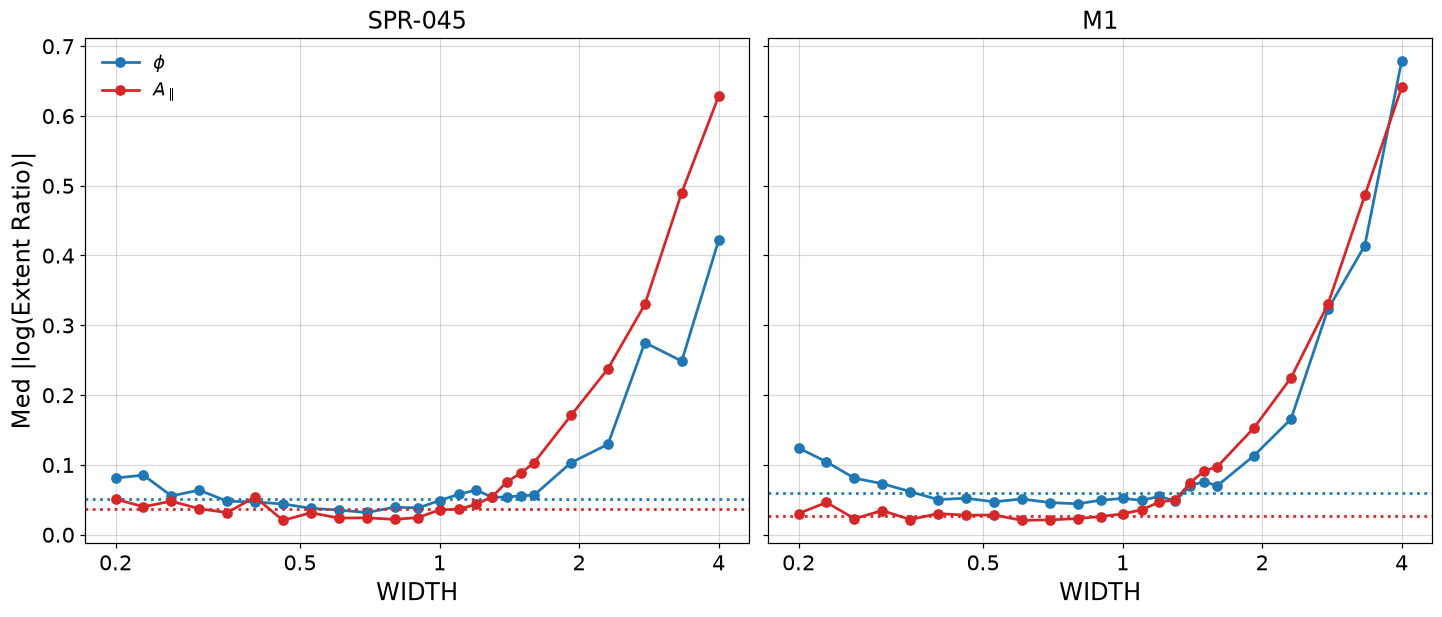

In [9]:
fig2, axes2 = plt.subplots(1, len(cases), figsize=(13, 5.5), sharey=True, squeeze=False)
for col, db in enumerate(cases):
    ax, res = axes2[0, col], full[db]
    for f, c in zip(fields, ("C0", "C3")):
        ax.plot(w_all, np.nanmedian(np.abs(lr(res["ext_dom"][f], res["ext_ref"][f][:, None])), axis=0), color=c, label=field_labels[f])
        ax.axhline(np.nanmedian(np.abs(lr(main[db]["D", "growth"]["ext"][f], res["ext_ref"][f]))), color=c, ls=":", marker="")
    ax.set(xscale="log", xlabel="WIDTH")
    ax.set_title(db, fontsize=fs_title)
    set_log_ticks(ax, [0.2, 0.5, 1, 2, 4])
axes2[0, 0].set_ylabel("Med |log(Extent Ratio)|")
axes2[0, 0].legend(fontsize=fs_legend)
plt.show()

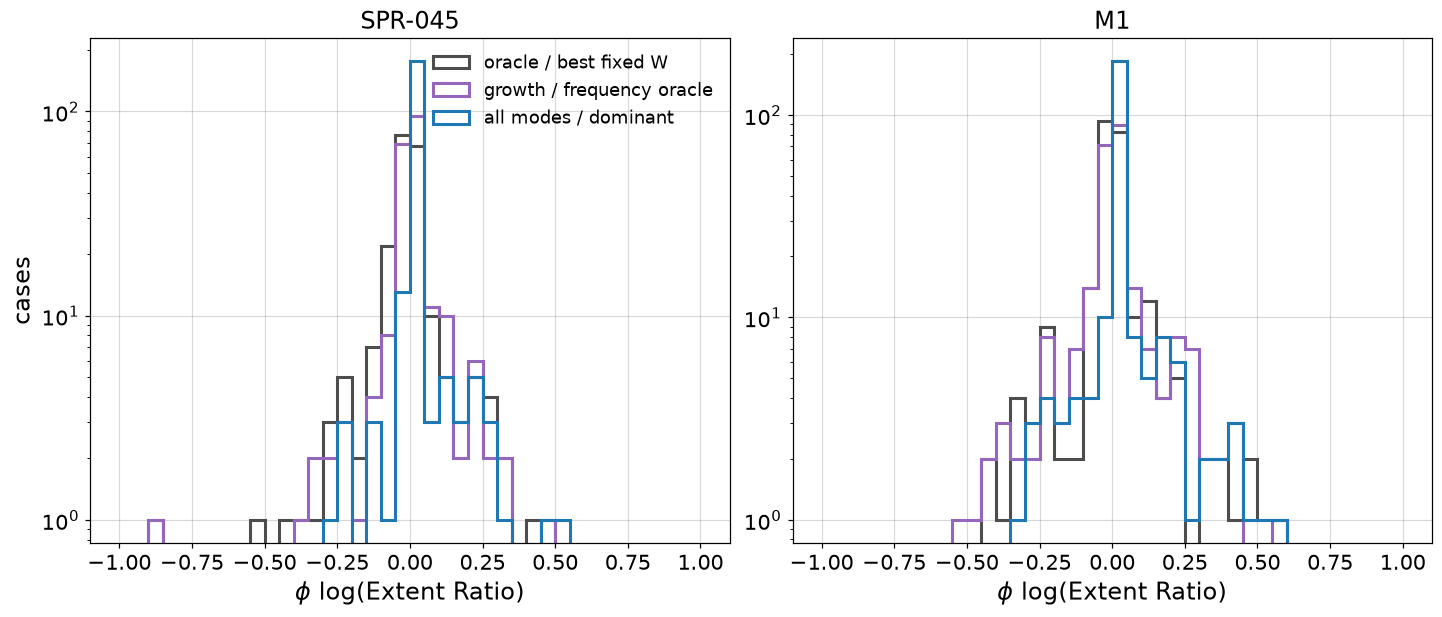

In [10]:
bins = np.linspace(-1, 1, 41)
fig3, axes3 = plt.subplots(1, len(cases), figsize=(13, 5.5), sharex=True, squeeze=False)
for col, (db, res) in enumerate(main.items()):
    ax = axes3[0, col]
    for x, lab, c in ((lr(res["D", "growth"]["ext"]["phi"], res["fixed", "growth"]["ext"]["phi"]), "oracle / best fixed W", "0.3"),
                      (lr(res["D", "growth"]["ext"]["phi"], res["D", "frequency"]["ext"]["phi"]), "growth / frequency oracle", "C4"),
                      (lr(res["A", "growth"]["ext"]["phi"], res["D", "growth"]["ext"]["phi"]), "all modes / dominant", "C0")):
        ax.hist(np.clip(x[np.isfinite(x)], bins[0], bins[-1]), bins=bins, histtype="step", color=c, lw=2, label=lab)
    ax.set(xlabel=r"$\phi$ log(Extent Ratio)", yscale="log")
    ax.set_title(db, fontsize=fs_title)
axes3[0, 0].set_ylabel("cases")
axes3[0, 0].legend(fontsize=fs_legend)
plt.show()

## Q2: what predicts the oracle width?

Per database and oracle: Spearman rho of log10(W_oracle) with each axis (bootstrap 68% interval); binned medians with
bootstrap bands; and a joint linear fit of log10 W_oracle on the standardised axes (log10 for axes spanning more than a
decade), with in-sample and `n_folds`-fold cross-validated R^2. The oracle gain (best-fixed-width error minus oracle
error) is correlated with the same axes to show where the choice matters. Note log W is **censored** at the range ends,
which caps any trend; the all-24-width repeat lifts that cap.

In [11]:
def log_axis(x):
    return bool((x > 0).all() and x.max() / x.min() > 10)


def boot_rho(x, y):
    ok = np.isfinite(x) & np.isfinite(y)
    x, y = x[ok], y[ok]
    rho = spearmanr(x, y).statistic
    b = [spearmanr(x[i], y[i]).statistic for i in rng.integers(0, len(x), (n_boot, len(x)))]
    return rho, *np.percentile(b, [16, 84]), len(x)


def joint_fit(P, y):
    X = np.column_stack([np.log10(P[p]) if log_axis(P[p].values) else P[p] for p in params])
    X = (X - X.mean(0)) / X.std(0)
    A = np.column_stack([np.ones(len(y)), X])
    coef = np.linalg.lstsq(A, y, rcond=None)[0]
    r2 = 1 - np.sum((y - A @ coef) ** 2) / np.sum((y - y.mean()) ** 2)
    pred = np.empty_like(y)
    for k in range(n_folds):
        test = np.arange(len(y)) % n_folds == k
        pred[test] = A[test] @ np.linalg.lstsq(A[~test], y[~test], rcond=None)[0]
    return coef[1:], r2, 1 - np.sum((y - pred) ** 2) / np.sum((y - y.mean()) ** 2)


def q2_rows(res, db, label):
    rows = []
    for o in ("D", "A"):
        for t in targets:
            logw = np.log10(res["widths"][res[o, t]["jw"]])
            coef, r2, r2cv = joint_fit(res["params"], logw)
            gain = res["fixed", t]["err"] - res[o, t]["err"]
            for p, c in zip(params, coef):
                rho, lo, hi, n = boot_rho(res["params"][p].values, logw)
                rho_gain = boot_rho(res["params"][p].values, gain)
                rows.append(dict(db=db, set=label, oracle=o, target=t, param=p, n=n, rho_logW=rho, rho_lo=lo, rho_hi=hi,
                                 coef_std=c, R2=r2, R2_cv=r2cv, rho_gain=rho_gain[0], n_gain=rho_gain[3]))
    return rows


q2 = pd.DataFrame([r for db, res in main.items() for r in q2_rows(res, db, "0.3-0.8")])
print(q2.round(3).to_string(index=False))

     db     set oracle    target                   param   n  rho_logW  rho_lo  rho_hi  coef_std    R2  R2_cv  rho_gain  n_gain
SPR-045 0.3-0.8      D    growth                      ky 220    -0.224  -0.293  -0.156    -0.039 0.179  0.101     0.091     220
SPR-045 0.3-0.8      D    growth                       q 220     0.131   0.064   0.197     0.003 0.179  0.101    -0.079     220
SPR-045 0.3-0.8      D    growth                    shat 220    -0.208  -0.269  -0.141    -0.033 0.179  0.101     0.135     220
SPR-045 0.3-0.8      D    growth                    beta 220    -0.250  -0.318  -0.188    -0.035 0.179  0.101     0.303     220
SPR-045 0.3-0.8      D    growth deuterium_temp_gradient 220     0.054  -0.017   0.125    -0.007 0.179  0.101     0.102     220
SPR-045 0.3-0.8      D    growth  electron_temp_gradient 220    -0.033  -0.098   0.040    -0.005 0.179  0.101     0.097     220
SPR-045 0.3-0.8      D    growth  electron_dens_gradient 220    -0.073  -0.137  -0.008    -0.008 0.179  

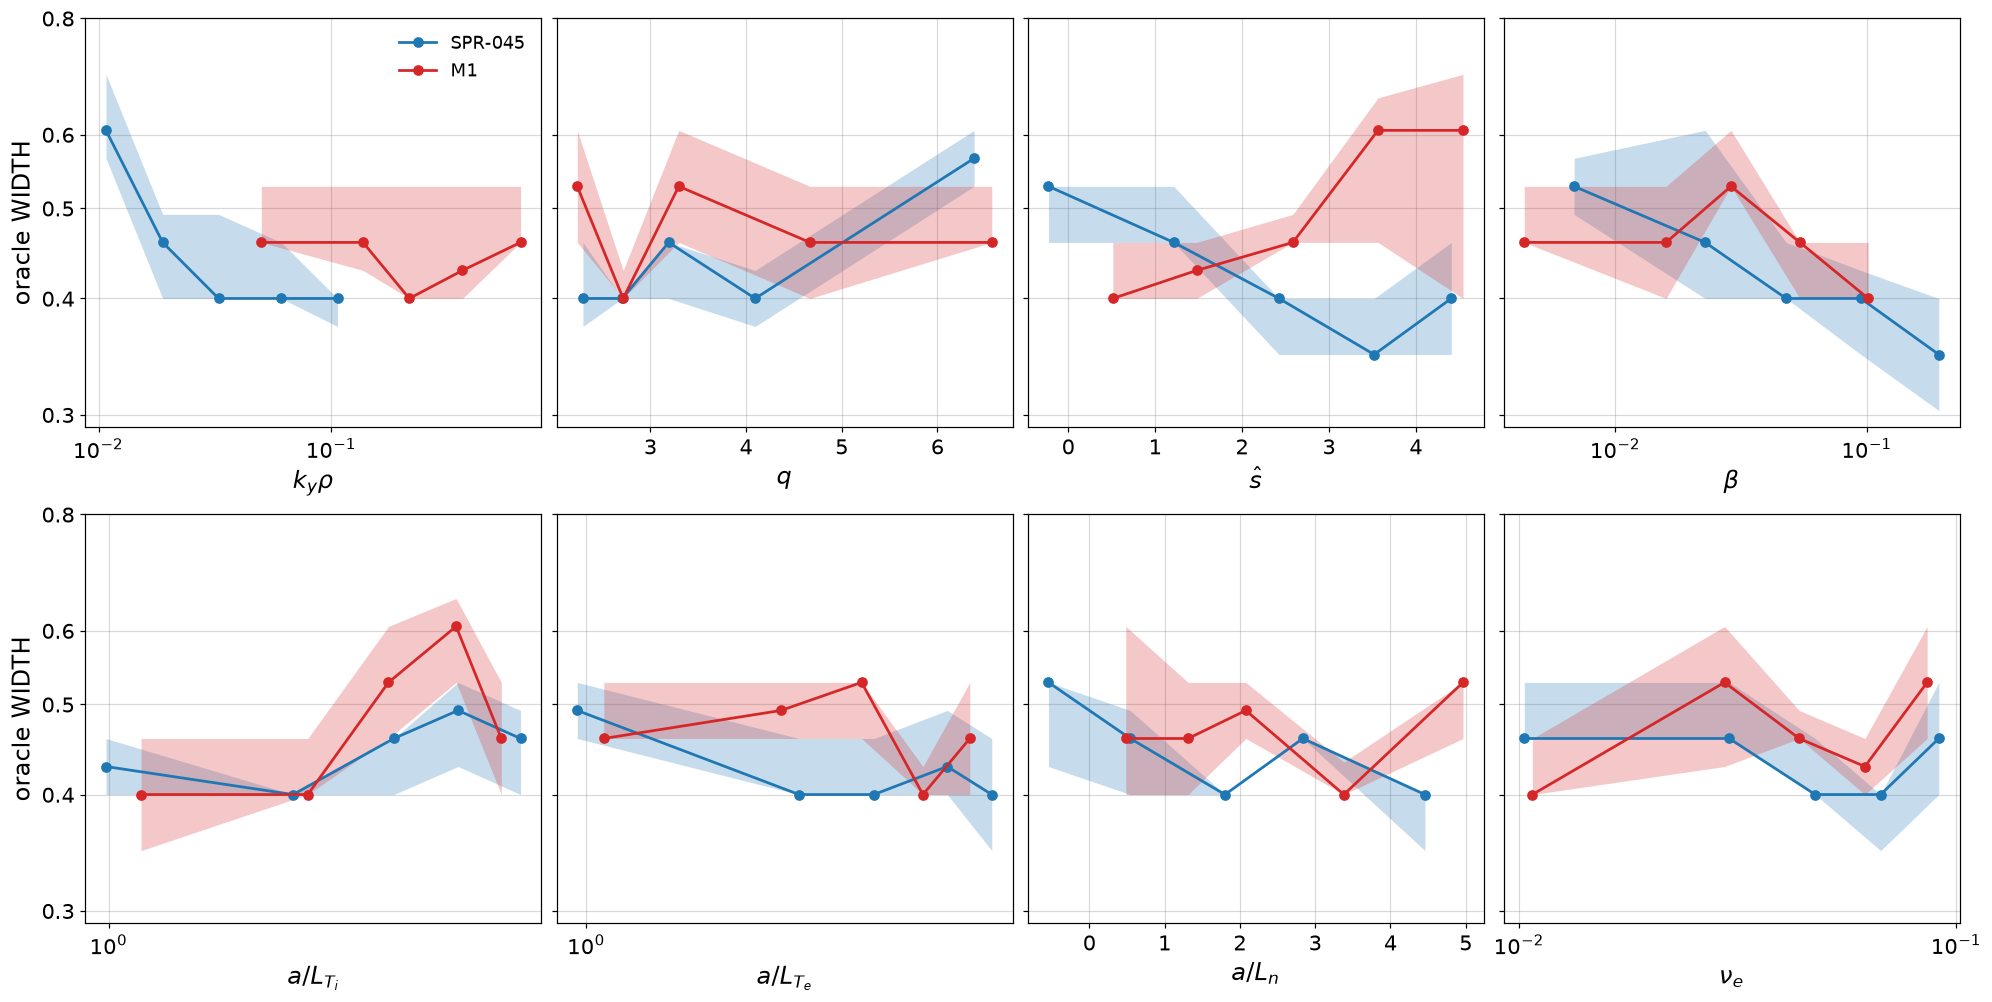

In [12]:
def binned(x, y):
    edges = np.quantile(x, np.linspace(0, 1, n_bins + 1))
    k = np.clip(np.searchsorted(edges, x, side="right") - 1, 0, n_bins - 1)
    mid = np.array([np.median(x[k == i]) for i in range(n_bins)])
    med = np.array([np.median(y[k == i]) for i in range(n_bins)])
    band = np.array([np.percentile([np.median(rng.choice(y[k == i], (k == i).sum())) for _ in range(n_boot)], [16, 84])
                     for i in range(n_bins)])
    return mid, med, band


def plot_width_vs_params(res_by_db, o, t, ticks):
    fig, axes = plt.subplots(2, 4, figsize=(18, 9), sharey=True)
    for (db, res), c in zip(res_by_db.items(), ("C0", "C3")):
        w = res["widths"][res[o, t]["jw"]]
        for ax, p in zip(axes.flat, params):
            x = res["params"][p].values
            mid, med, band = binned(x, np.log10(w))
            ax.fill_between(mid, 10 ** band[:, 0], 10 ** band[:, 1], color=c, alpha=0.25, lw=0)
            ax.plot(mid, 10 ** med, color=c, marker="o", label=db)
            ax.set(xscale="log" if all(log_axis(r["params"][p].values) for r in res_by_db.values()) else "linear", yscale="log")
            ax.set_xlabel(param_labels[p])
    for ax in axes[:, 0]:
        ax.set_ylabel("oracle WIDTH")
        ax.set_yticks(ticks)
        ax.yaxis.set_major_formatter(StrMethodFormatter("{x:g}"))
    for ax in axes.flat:
        ax.minorticks_off()
    axes[0, 0].legend(fontsize=fs_legend)
    return fig


fig4 = plot_width_vs_params(main, "D", "growth", [0.3, 0.4, 0.5, 0.6, 0.8])
plt.show()

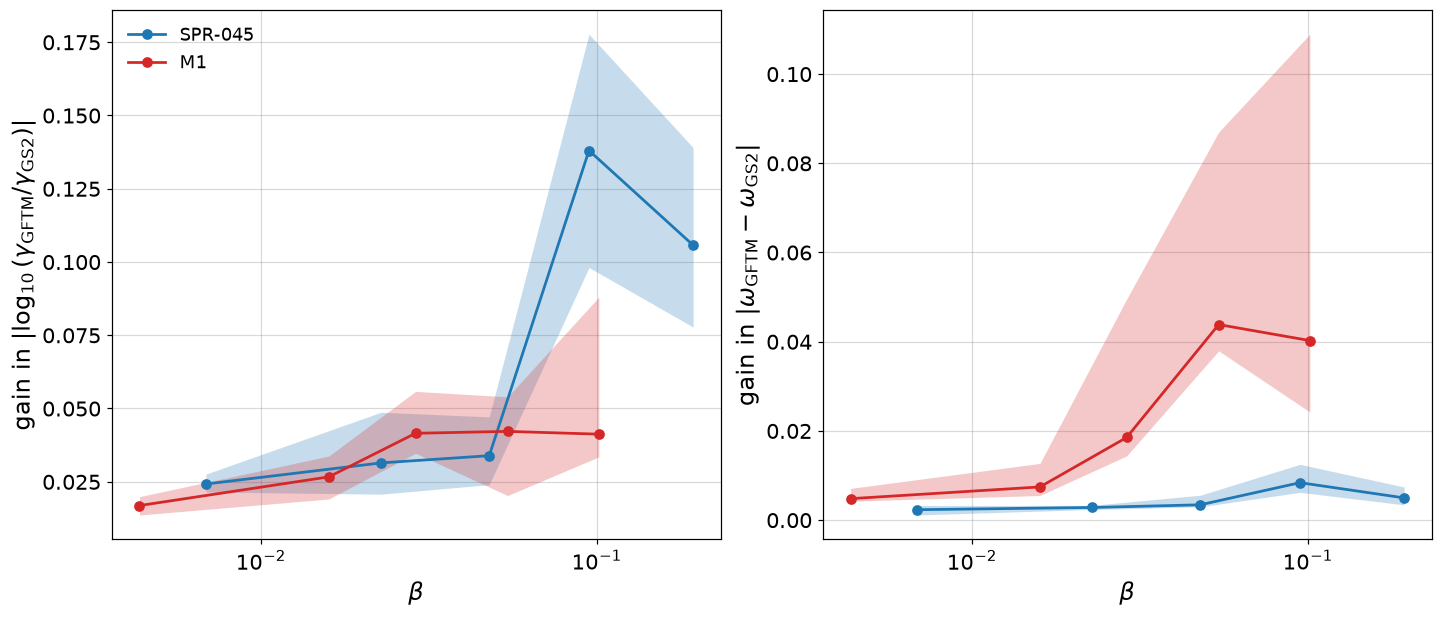

In [13]:
# where the width choice matters: oracle gain (best fixed W error - oracle error) vs beta
fig6, axes6 = plt.subplots(1, len(targets), figsize=(13, 5.5), squeeze=False)
for ax, t in zip(axes6[0], targets):
    for (db, res), c in zip(main.items(), ("C0", "C3")):
        gain = res["fixed", t]["err"] - res["D", t]["err"]
        x = res["params"]["beta"].values
        ok = np.isfinite(gain)
        mid, med, band = binned(x[ok], gain[ok])
        ax.fill_between(mid, band[:, 0], band[:, 1], color=c, alpha=0.25, lw=0)
        ax.plot(mid, med, color=c, label=db)
    ax.set(xscale="log", xlabel=param_labels["beta"],
           ylabel=r"gain in $|\log_{10}(\gamma_{\rm GFTM}/\gamma_{\rm GS2})|$" if t == "growth" else r"gain in $|\omega_{\rm GFTM}-\omega_{\rm GS2}|$")
    ax.minorticks_off()
axes6[0, 0].legend(fontsize=fs_legend)
plt.show()

## Checks: all 24 widths, and GS2-classified KBMs only

The same Q1/Q2 numbers (a) with the oracle free over all 24 widths 0.2-4.0, and (b) on the cases whose GS2 run the
consensus classifier labels KBM (all four indicators: T < 0.05, omega > 0, 0.5 < chi_e/chi_i < 2, D_e/chi_e > 0.4;
cutoffs are the module's). A failed load or non-finite classification is not KBM; failures are counted.

In [14]:
def classify_run(args):
    db, name = args
    try:
        pyro = Pyro(gk_file=data_root / "GS2" / run_template / project / cases[db] / scan_information["GS2"] / name / "gs2.in")
        pyro.load_gk_output(load_fields=True, load_fluxes=True)
        return db, name, mc.classify(mc.indicators(pyro))
    except Exception as e:
        return db, name, "load_failed"


warnings.filterwarnings("ignore")
jobs = [(db, n) for db, v in data05.items() for n in v["names"].astype(str)]
with get_context("fork").Pool(int(os.environ.get("SLURM_CPUS_PER_TASK", 4))) as pool:   # 3.14 default is forkserver: notebook functions do not pickle
    label = {(db, n): l for db, n, l in pool.map(classify_run, jobs, chunksize=4)}
kbm = {db: np.array([label[db, n] == "KBM" for n in v["names"].astype(str)]) for db, v in data05.items()}
for db in cases:
    labs = pd.Series([l for (d, _), l in label.items() if d == db])
    print(db, labs.value_counts().to_dict(), "| KBM in population:", kbm[db].sum())

/pitagora_work/FUPB2_QLTURB/fwatts/ga-wt-38e96/.venv/lib/python3.14/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


/pitagora_work/FUPB2_QLTURB/fwatts/ga-wt-38e96/.venv/lib/python3.14/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


/pitagora_work/FUPB2_QLTURB/fwatts/ga-wt-38e96/.venv/lib/python3.14/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


/pitagora_work/FUPB2_QLTURB/fwatts/ga-wt-38e96/.venv/lib/python3.14/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


/pitagora_work/FUPB2_QLTURB/fwatts/ga-wt-38e96/.venv/lib/python3.14/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


...

/pitagora_work/FUPB2_QLTURB/fwatts/ga-wt-38e96/.venv/lib/python3.14/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


/pitagora_work/FUPB2_QLTURB/fwatts/ga-wt-38e96/.venv/lib/python3.14/site-packages/pyrokinetics/gk_code/gk_output.py:694: UserWarning: Mode frequency may not be accurate due to low temporal resolution
  warnings.warn(


/pitagora_work/FUPB2_QLTURB/fwatts/ga-wt-38e96/.venv/lib/python3.14/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


/pitagora_work/FUPB2_QLTURB/fwatts/ga-wt-38e96/.venv/lib/python3.14/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


SPR-045 {'mixed': 150, 'KBM': 70} | KBM in population: 70
M1 {'mixed': 120, 'KBM': 114, 'MTM': 18} | KBM in population: 114


                                               n  medErr_fixed  medErr_oracle  W_fixed  frac_at_end  phi_medAbsLog_oracle_vs_gs2  phi_medAbsLog_fixed_vs_gs2  phi_medLog_oracle_vs_fixed  phi_frac_oracle_within2_fixed  apar_medAbsLog_oracle_vs_gs2  apar_medAbsLog_fixed_vs_gs2  phi_medSpread_all  phi_medSpread_10pct  phi_medSpread_50pct
db      set     population oracle target                                                                                                                                                                                                                                                                                                       
SPR-045 0.3-0.8 all        D      growth     220         0.096          0.030    0.800        0.418                        0.051                       0.039                      -0.002                          0.959                         0.037                        0.022              0.059                  0.0              

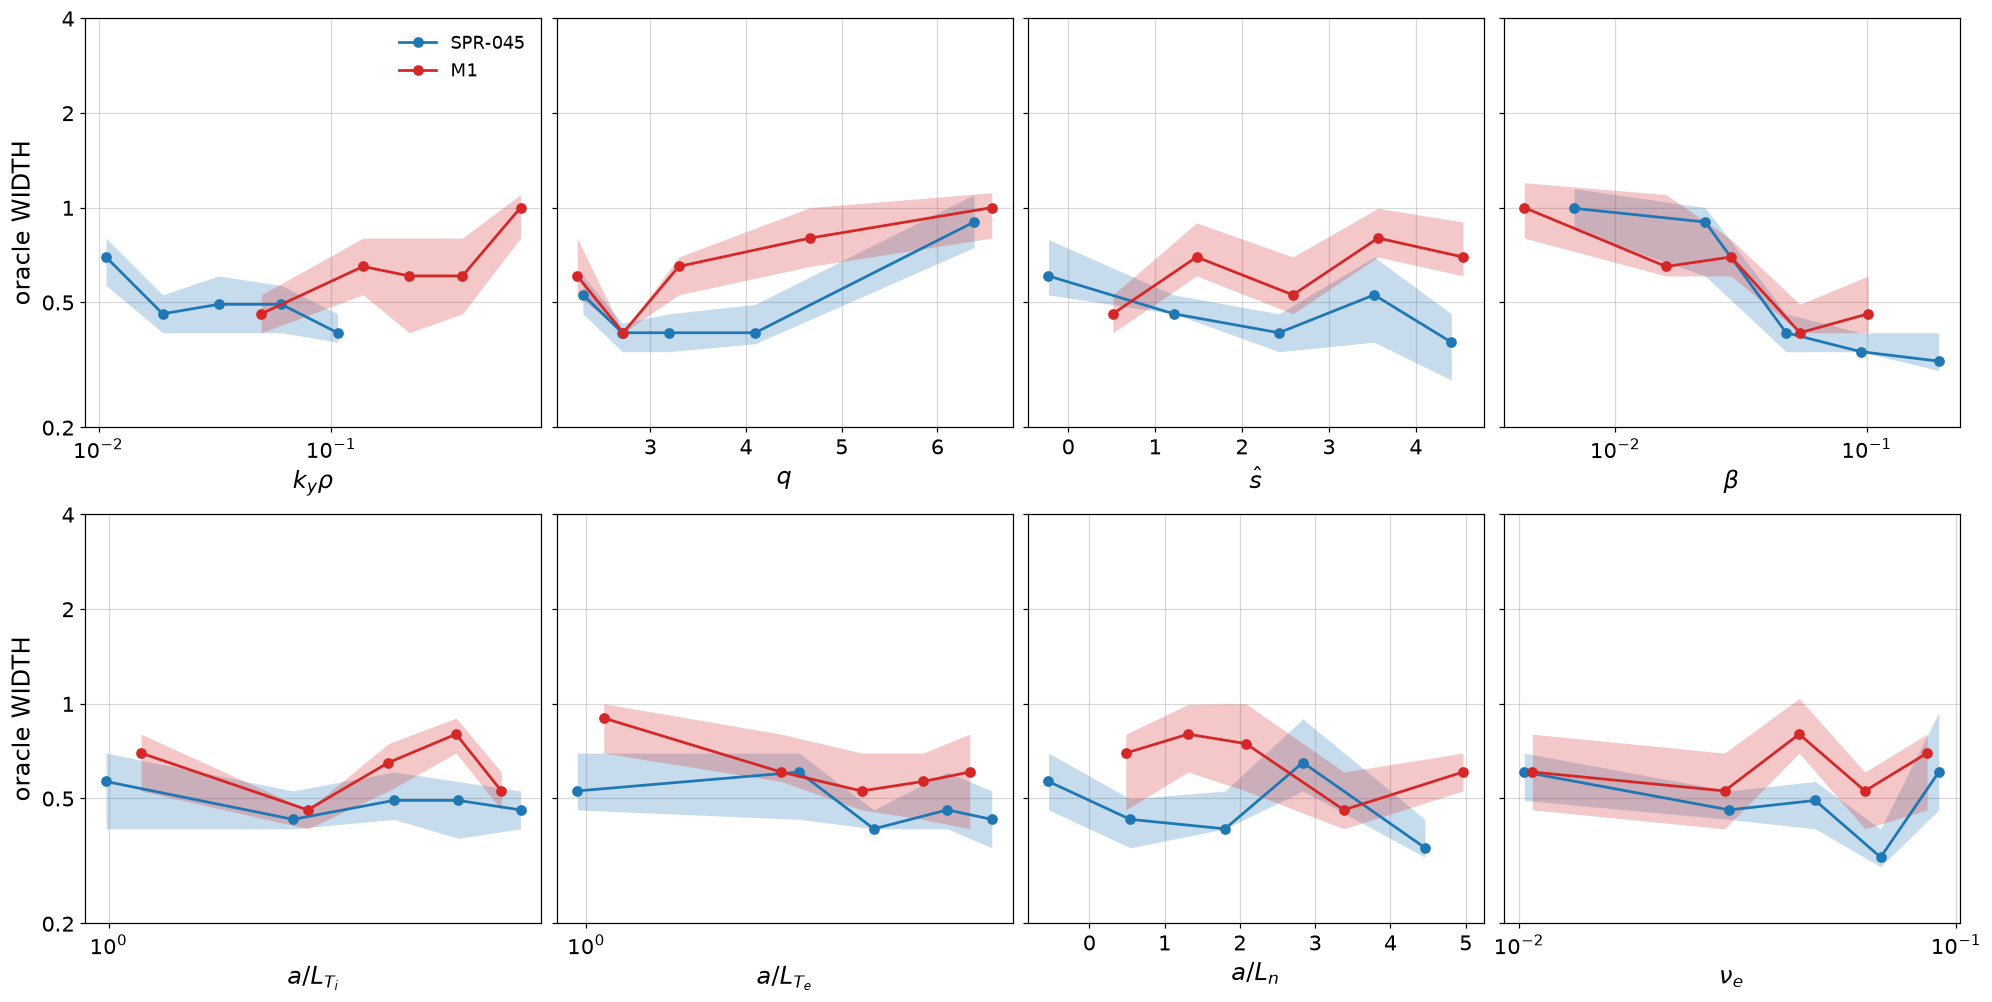

In [15]:
checks = {("0.2-4.0", "all"): {db: oracles(v, iw_all, everyone[db]) for db, v in data05.items()},
          ("0.3-0.8", "KBM"): {db: oracles(v, iw_range, kbm[db]) for db, v in data05.items()},
          ("0.2-4.0", "KBM"): {db: oracles(v, iw_all, kbm[db]) for db, v in data05.items()}}
q1_all = pd.concat([q1.assign(population="all")] + [pd.DataFrame([r for db, res in rr.items() for r in q1_rows(res, db, s)]).assign(population=pop)
                                                     for (s, pop), rr in checks.items()], ignore_index=True)
q2_all = pd.concat([q2.assign(population="all")] + [pd.DataFrame([r for db, res in rr.items() for r in q2_rows(res, db, s)]).assign(population=pop)
                                                     for (s, pop), rr in checks.items()], ignore_index=True)
key = ["db", "set", "population", "oracle", "target"]
print(q1_all.set_index(key)[["n", "medErr_fixed", "medErr_oracle", "W_fixed", "frac_at_end", "phi_medAbsLog_oracle_vs_gs2",
                             "phi_medAbsLog_fixed_vs_gs2", "phi_medLog_oracle_vs_fixed", "phi_frac_oracle_within2_fixed",
                             "apar_medAbsLog_oracle_vs_gs2", "apar_medAbsLog_fixed_vs_gs2", "phi_medSpread_all", "phi_medSpread_10pct",
                             "phi_medSpread_50pct"]].round(3).to_string())
top = q2_all.loc[q2_all.groupby(key).rho_logW.apply(lambda x: x.abs().idxmax())].set_index(key)
top_gain = q2_all.loc[q2_all.groupby(key).rho_gain.apply(lambda x: x.abs().idxmax())].set_index(key)
print(top[["n", "R2", "R2_cv", "param", "rho_logW"]].join(top_gain[["param", "rho_gain"]], rsuffix="_gain").round(3).to_string())
fig5 = plot_width_vs_params(checks["0.2-4.0", "all"], "D", "growth", [0.2, 0.5, 1, 2, 4])
plt.show()

## Save

In [16]:
out = ROOT / "Plots" / analysis_name
out.mkdir(parents=True, exist_ok=True)
for name, fig in (("fig1_error_vs_width", fig1), ("fig2_extent_ratio_vs_width", fig2), ("fig3_extent_ratio_oracle_choices", fig3),
                  ("fig4_oracle_width_vs_params", fig4), ("fig5_oracle_width_vs_params_allwidths", fig5),
                  ("fig6_oracle_gain_vs_beta", fig6)):
    fig.savefig(out / f"{name}.png", bbox_inches="tight")
# small summary tables only (no per-case rows)
q1_all.round(4).to_csv(out / "q1_extent_summary.csv", index=False)
q2_all.round(4).to_csv(out / "q2_width_predictors.csv", index=False)
param_ranges.to_csv(out / "kbm_8d_parameter_ranges.csv")
print(sorted(p.name for p in out.iterdir()))

['fig1_error_vs_width.png', 'fig2_extent_ratio_vs_width.png', 'fig3_extent_ratio_oracle_choices.png', 'fig4_oracle_width_vs_params.png', 'fig5_oracle_width_vs_params_allwidths.png', 'fig6_oracle_gain_vs_beta.png', 'kbm_8d_parameter_ranges.csv', 'q1_extent_summary.csv', 'q2_width_predictors.csv', 'superseded_v1']
